In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.5
# target_freq = 10.3875

In [152]:
def fit_waveform(time, data, x0=[2e-3,400], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

# def target_overlap(wave, time, curve='sech'):
#     wave = np.abs(wave) ### changed by Sunada
#     wave_rev = np.flip(wave)
#     if curve=='sech':
#         target = 1 / np.cosh(const * (time-time[-1]/2))
#     elif curve=="sech_1":
#         target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_2":
#         target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_3":
#         target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
#     target = np.abs(target)
#     norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
#     norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
#     m=0 ;c=[]
#     for i in range(len(wave)):
#         wave_rev_i = np.roll(wave_rev, i)
#         mult = target*wave_rev_i
#         mult_sum=np.sum(mult) * (time[1] - time[0])
#         cand = np.abs(mult_sum)**2
#         c.append(cand/norm)
#         if m<cand:
#             m=cand
#     return m / norm / norm_target

def target_overlap(wave, time, curve='sech'):
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="sech_1":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_2":
        target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_3":
        target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
    norm1=np.sqrt(np.sum(np.abs(wave)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(target)**2) * (time[1]-time[0]))
    m1_t = np.abs(wave / norm1)
    m2_t = target / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

# symmetrical shape

In [3]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2024-09-20", acquire_time="224531", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.15, date="2024-09-21", acquire_time="000452", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data3 = dict(amp=0.2, date="2024-09-21", acquire_time="012413", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.25, date="2024-09-21", acquire_time="024338", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data5 = dict(amp=0.3, date="2024-09-21", acquire_time="031646", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.35, date="2024-09-21", acquire_time="035001", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data7 = dict(amp=0.4, date="2024-09-21", acquire_time="042322", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data8 = dict(amp=0.45, date="2024-09-21", acquire_time="045614", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data9 = dict(amp=0.5, date="2024-09-21", acquire_time="184735", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data10 = dict(amp=0.55, date="2024-09-21", acquire_time="191718", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data11 = dict(amp=0.6, date="2024-09-21", acquire_time="195246", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data12 = dict(amp=0.7, date="2024-09-21", acquire_time="202230", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data13 = dict(amp=0.8, date="2024-09-21", acquire_time="205144", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data125 = dict(amp=1.25, date="2023-12-27", acquire_time="041444", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data13 = dict(amp=1.075, date="2024-2-20", acquire_time="203046", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data14 = dict(amp=1.1, date="2023-12-27", acquire_time="102535", params=dict(fit_start=50, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.125, date="2023-12-27", acquire_time="101913", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.2, date="2023-12-27", acquire_time="035436", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data16 = dict(amp=1.3, date="2024-2-20", acquire_time="195024", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data17 = dict(amp=1.4, date="2023-12-27", acquire_time="045145", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data18 = dict(amp=1.45, date="2023-12-27", acquire_time="052020", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data181 = dict(amp=1.48, date="2023-12-27", acquire_time="054855", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data182 = dict(amp=1.49, date="2023-12-27", acquire_time="061732", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data19 = dict(amp=1.3, date="2023-12-27", acquire_time="111410", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

# Generating Control Pulses

In [4]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.1 2024-09-20 224531
0.15 2024-09-21 000452
0.2 2024-09-21 012413
0.25 2024-09-21 024338
0.3 2024-09-21 031646
0.35 2024-09-21 035001
0.45 2024-09-21 045614
0.5 2024-09-21 184735
0.55 2024-09-21 191718
0.6 2024-09-21 195246
0.7 2024-09-21 202230
0.8 2024-09-21 205144


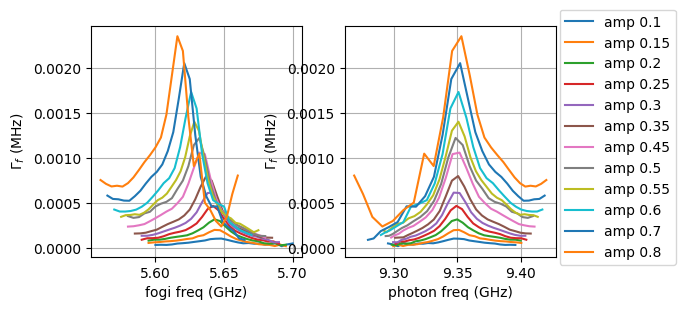

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}


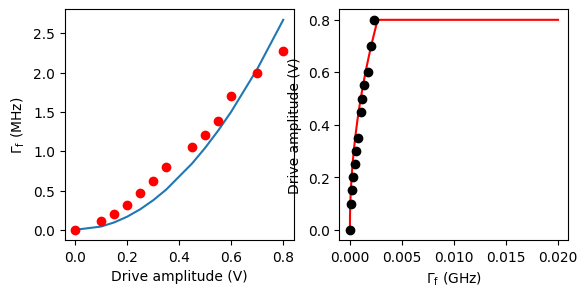

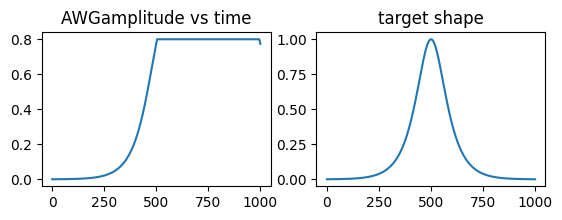

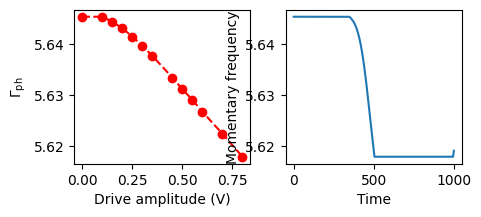

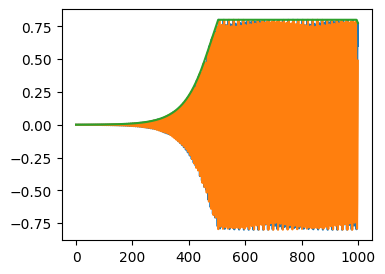

In [153]:
form = "sech_0"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

## save

In [31]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
duration = 1000
for target_freq in [9.33, 9.35, 9.37]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.001648235046157298, 'a4': 8.975487020279616e-12, 'a6': 1.8698376180736886e-12, 'a8': 2.2213342276700132e-12, 'a10': 2.220446049250313e-16}
{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
{'a0': 0, 'a2': 0.002245387841872004, 'a4': 3.780087354243733e-12, 'a6': 1.894262524615442e-12, 'a8': 4.0478731477833207e-13, 'a10': 3.228528555609955e-13}


# Photon shaping analysis

In [154]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-21", acquire_time="223335"),
    data1 = dict(target_freq=9.35, date="2024-09-21", acquire_time="224025"),
    data2 = dict(target_freq=9.37, date="2024-09-21", acquire_time="224714"),
    # data3 = dict(target_freq=10.3850, date="2024-07-26", acquire_time="002649"),
    # data4 = dict(target_freq=10.3875, date="2024-07-26", acquire_time="003339"),
    # data5 = dict(target_freq=10.3900, date="2024-07-26", acquire_time="004028"),
    # data6 = dict(target_freq=10.3925, date="2024-07-26", acquire_time="004718"),
    # data7 = dict(target_freq=10.3950, date="2024-07-26", acquire_time="005408"),
    # data8 = dict(target_freq=10.3975, date="2024-07-26", acquire_time="010058"),
)

symmetry 0.7623523223927197, overlap 0.7439711212675254
symmetry 0.9752536376701116, overlap 0.9847957772191441
symmetry 0.8119134469783177, overlap 0.8589118016186477


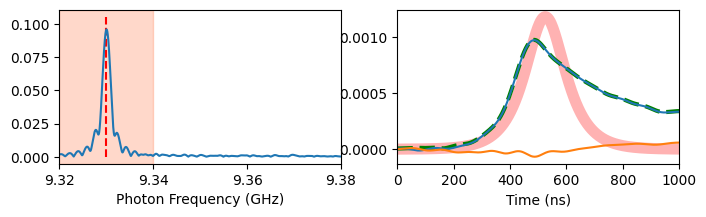

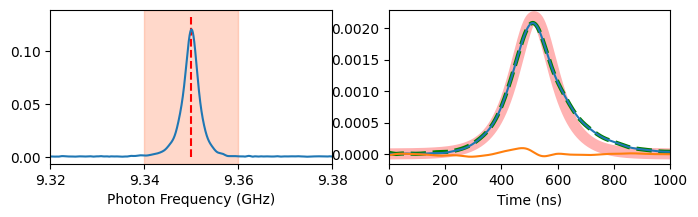

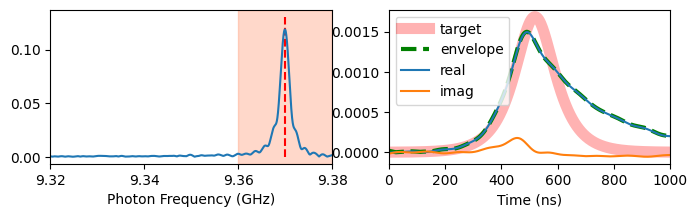

In [155]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()

phase substraction

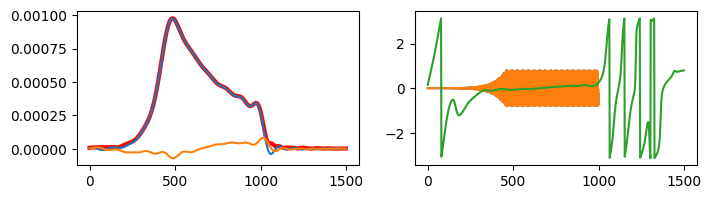

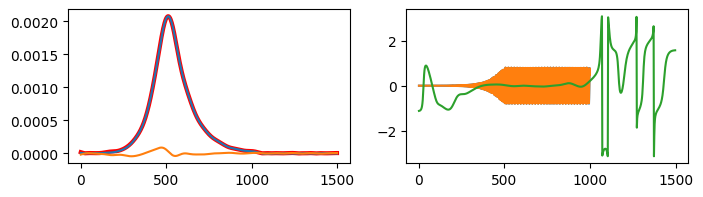

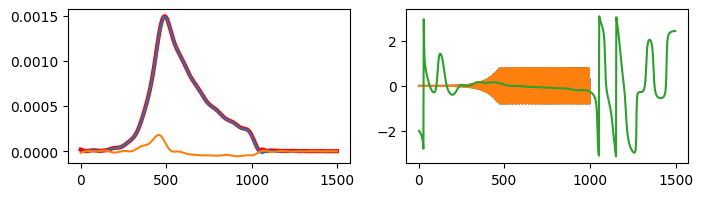

In [34]:
# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

corrected photon shaping

In [156]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-21", acquire_time="225733"),
    data1 = dict(target_freq=9.35, date="2024-09-21", acquire_time="230423"),
    data2 = dict(target_freq=9.37, date="2024-09-21", acquire_time="231112"),
    # data4 = dict(target_freq=10.3875, date="2024-07-26", acquire_time="083005"),
    # data5 = dict(target_freq=10.3900, date="2024-07-26", acquire_time="083655"),
    # data6 = dict(target_freq=10.3925, date="2024-07-26", acquire_time="084345"),
    # data7 = dict(target_freq=10.3950, date="2024-07-26", acquire_time="085035"),
)


symmetry 0.7846780063172474, overlap 0.7526542112276465
symmetry 0.9710331048666948, overlap 0.9847902770546697
symmetry 0.8002180072197163, overlap 0.8355098145269529


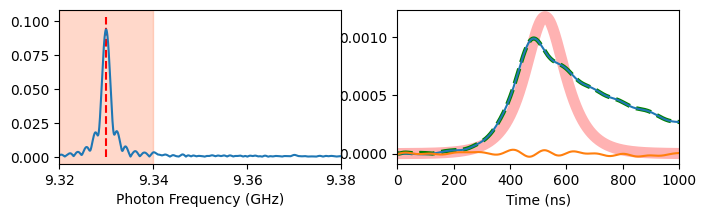

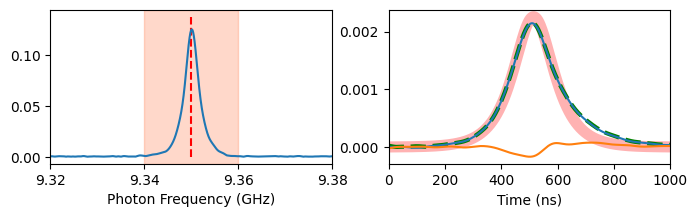

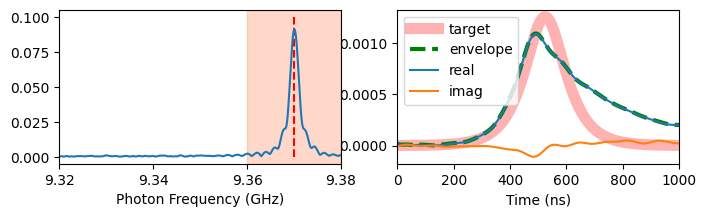

In [157]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()


fogi pulse generation for absoption

In [ ]:
date = "2024-07-29"
acquire_time="052057"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

# othogonal mode

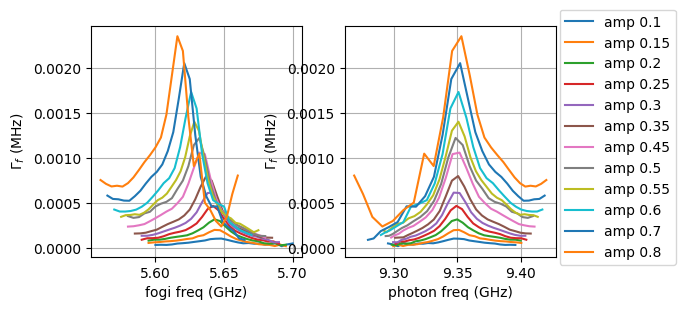

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}


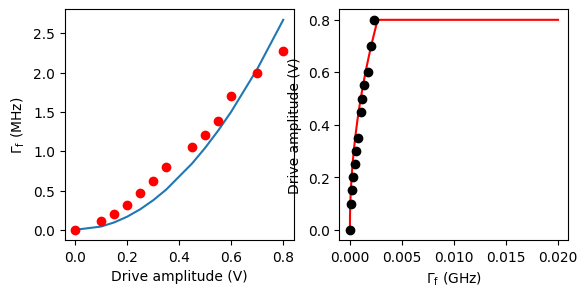

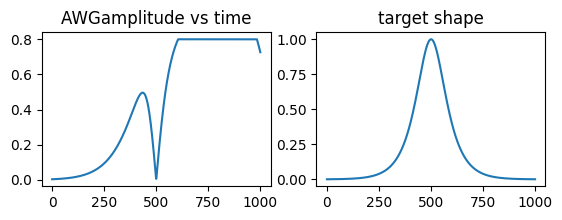

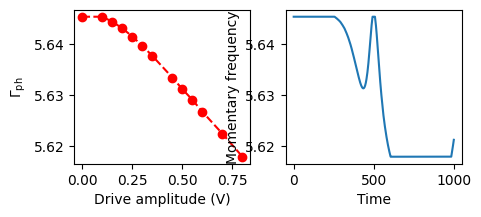

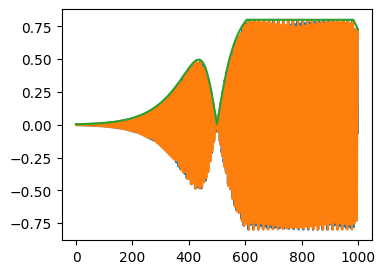

In [158]:
form = "sech_1"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [7]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.33, 9.35, 9.37]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape_othogonal.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.001648235046157298, 'a4': 8.975487020279616e-12, 'a6': 1.8698376180736886e-12, 'a8': 2.2213342276700132e-12, 'a10': 2.220446049250313e-16}
{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
{'a0': 0, 'a2': 0.002245387841872004, 'a4': 3.780087354243733e-12, 'a6': 1.894262524615442e-12, 'a8': 4.0478731477833207e-13, 'a10': 3.228528555609955e-13}


In [30]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[433 498 604 981]


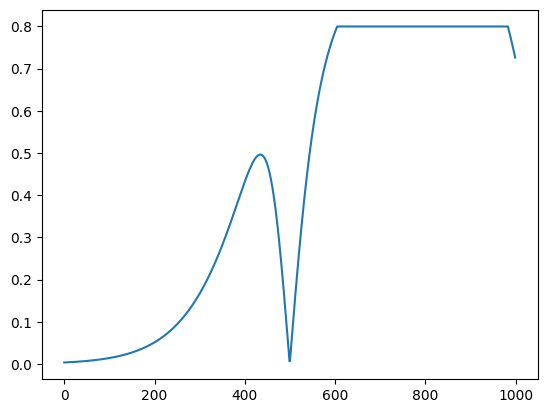

In [31]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

In [159]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="164420"),
    data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="165110"),
    data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="165759"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

overlap 0.9033632040387654
overlap 0.9665470481119621
overlap 0.948684954020848


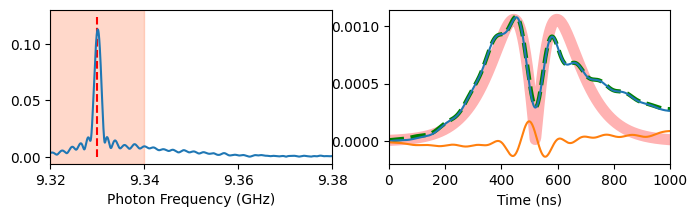

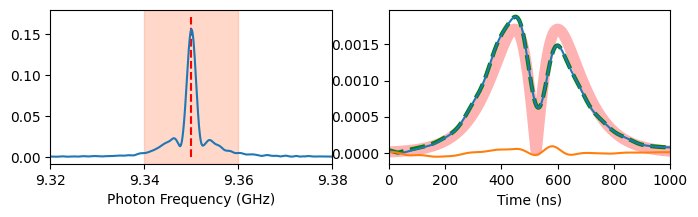

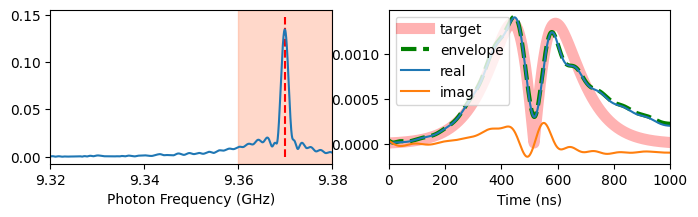

In [160]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_1", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_1')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
plt.legend()

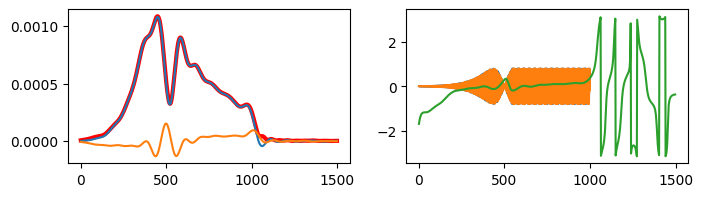

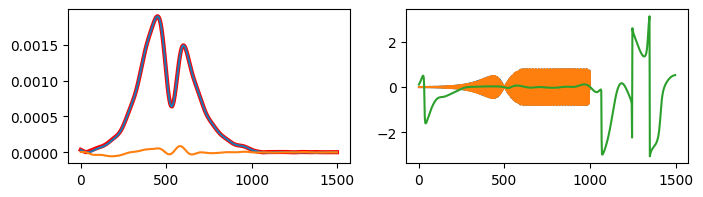

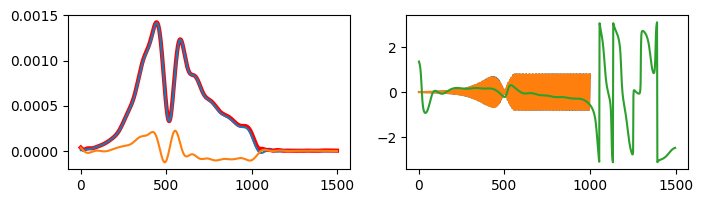

In [17]:
# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    for i in range(0, int(len(new_ctrl_pulse)/2)):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape_othogonal.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [161]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="171715"),
    data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="172404"),
    data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="173054"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

 overlap 0.8888638394539671
 overlap 0.9736194901665653
 overlap 0.940130956340723


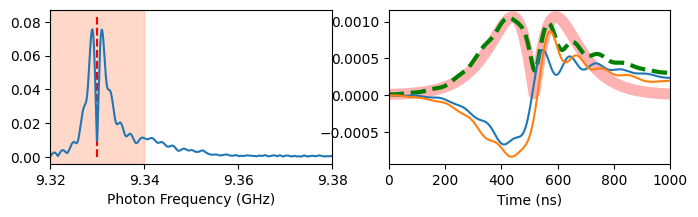

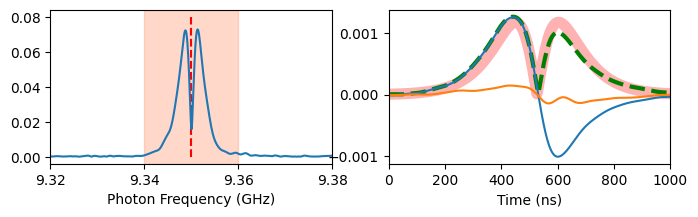

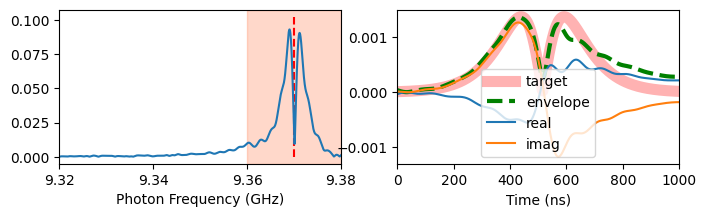

In [162]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_1", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f" overlap {target_overlap(signal, time, curve='sech_1')}")
plt.legend()

receive

In [61]:
result_dict = dict(
    data1 = dict(target_freq=10.3875, date="2024-07-26", acquire_time="161818"),
)

In [ ]:
date = "2024-07-29"
acquire_time="052057"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse_othogonal") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape_othogonal.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

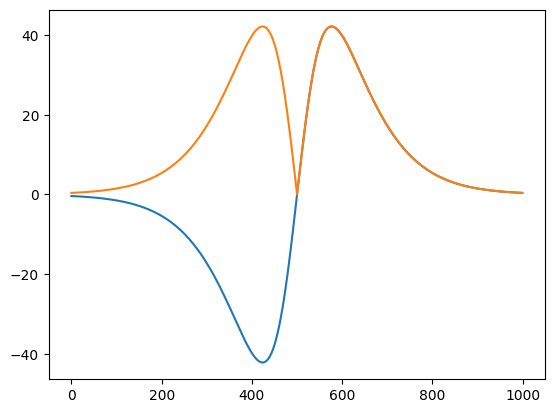

In [12]:
fogi_duration = 1000
ph_if = readout_lo_freq*1e9 - 10.3875*1e9
x = np.linspace(0, 999, 1000)
const = 2.5e-3 * 2 * np.pi
ph_waveform =(x - fogi_duration/2)/np.cosh(const * (x - fogi_duration/2))#*np.cos(2*np.pi* ph_if*x*1e-9) #1/np.cosh(const * (x - fogi_duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) 

plt.plot(x, ph_waveform)
plt.plot(x, np.abs(ph_waveform))

sech_2

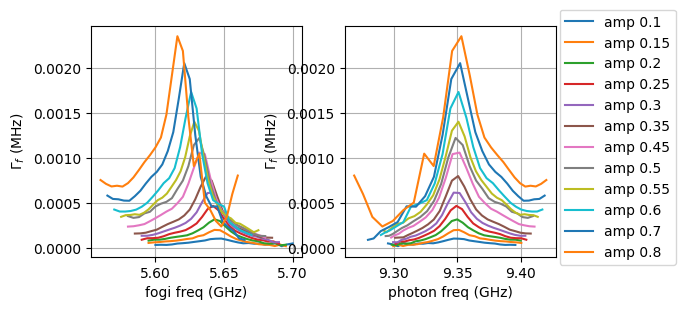

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}


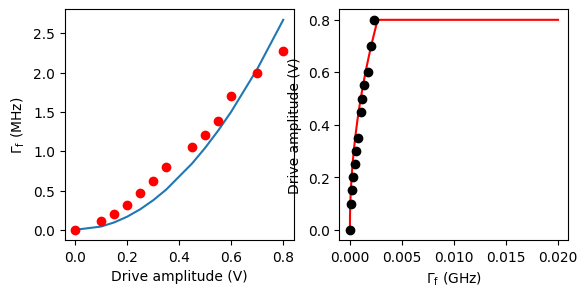

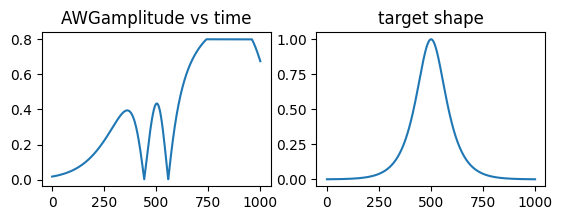

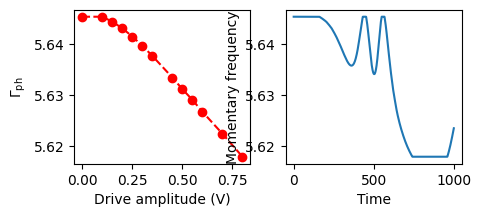

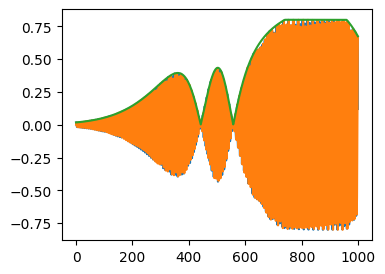

In [173]:
form = "sech_2"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [174]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.33, 9.35, 9.37]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape_othogonal.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.001648235046157298, 'a4': 8.975487020279616e-12, 'a6': 1.8698376180736886e-12, 'a8': 2.2213342276700132e-12, 'a10': 2.220446049250313e-16}
{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
{'a0': 0, 'a2': 0.002245387841872004, 'a4': 3.780087354243733e-12, 'a6': 1.894262524615442e-12, 'a8': 4.0478731477833207e-13, 'a10': 3.228528555609955e-13}


In [175]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[359 441 501 556 740 957]
1000


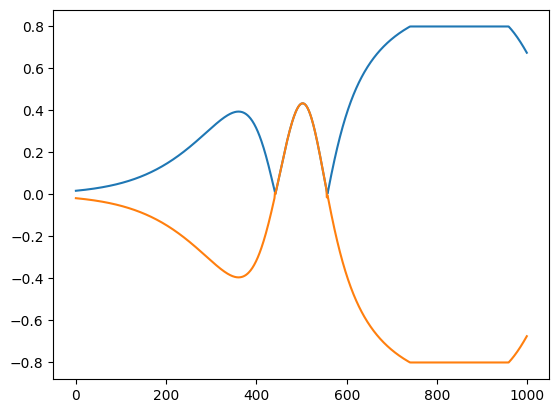

In [176]:
import itertools
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

# for i in range(len(control_envelope)):
#     control_envelope[i] = -control_envelope[i]
for i in itertools.chain(range(0, 441), range(556, len(control_envelope))):
    control_envelope[i] = -control_envelope[i]
plt.plot(control_envelope)
print(len(control_envelope))

In [179]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="174456"),
    # data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="175146"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="175835"),
    data0 = dict(target_freq=9.33, date="2024-09-23", acquire_time="110926"),
    data1 = dict(target_freq=9.35, date="2024-09-23", acquire_time="111615"),
    data2 = dict(target_freq=9.37, date="2024-09-23", acquire_time="112305"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

overlap 0.950795272406204
overlap 0.9579927704879007
overlap 0.9733111679411909


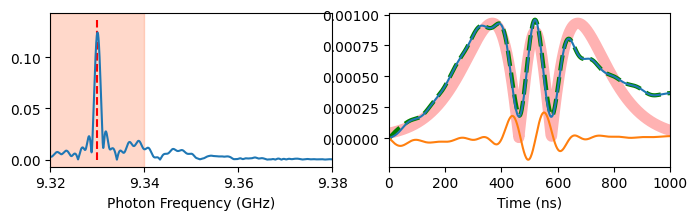

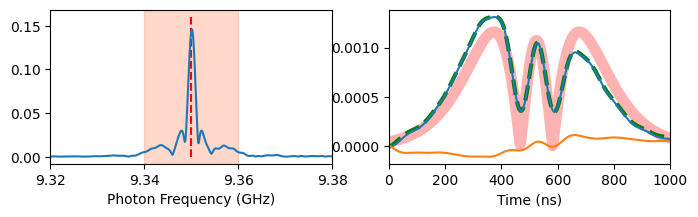

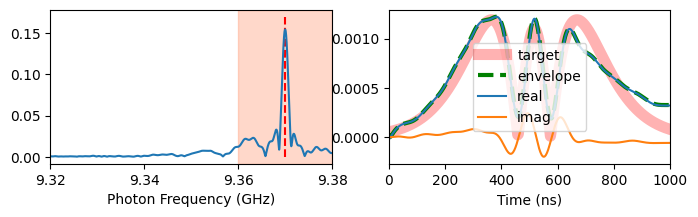

In [180]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_2", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_2')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
plt.legend()

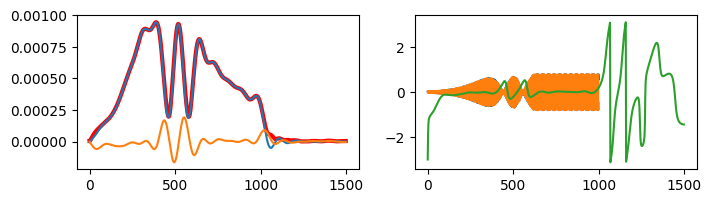

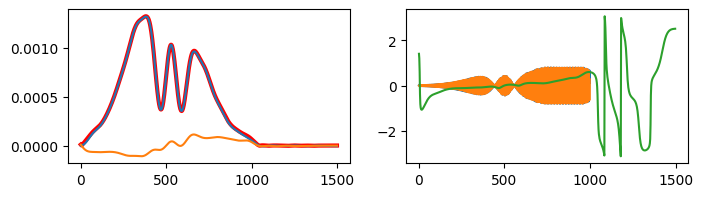

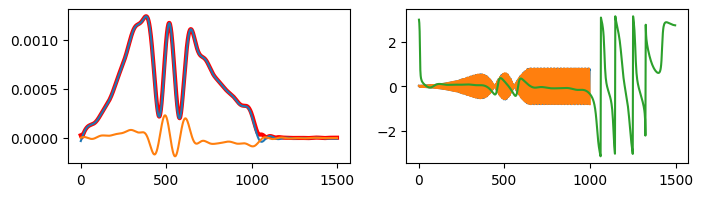

In [181]:
import itertools

# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    for i in itertools.chain(range(0, 441), range(556, len(new_ctrl_pulse))):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape_othogonal.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [185]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="182617"),
    # data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="183307"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="183956"),
    data0 = dict(target_freq=9.33, date="2024-09-23", acquire_time="113221"),
    data1 = dict(target_freq=9.35, date="2024-09-23", acquire_time="113910"),
    data2 = dict(target_freq=9.37, date="2024-09-23", acquire_time="114600"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

 overlap 0.9446969859116295
 overlap 0.9535734943543293
 overlap 0.9734208121144299


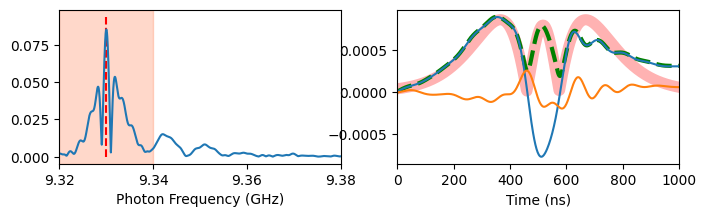

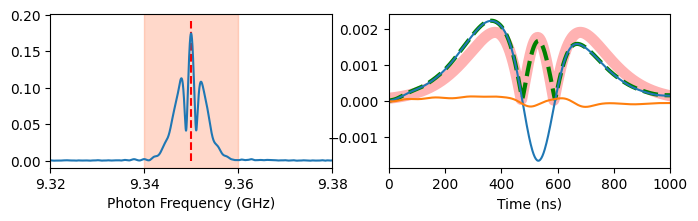

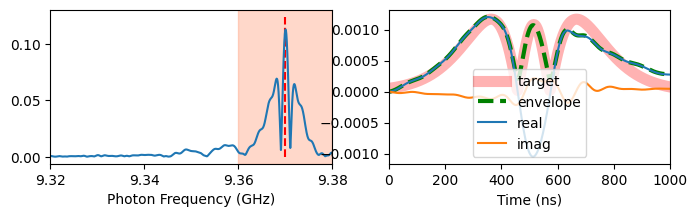

In [186]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_2", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f" overlap {target_overlap(signal, time, curve='sech_2')}")
plt.legend()

receive

In [ ]:
result_dict = dict(
    data1 = dict(target_freq=10.3875, date="2024-07-26", acquire_time="161818"),
)

In [ ]:
date = "2024-07-29"
acquire_time="052057"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse_othogonal") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape_othogonal.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

sech_3

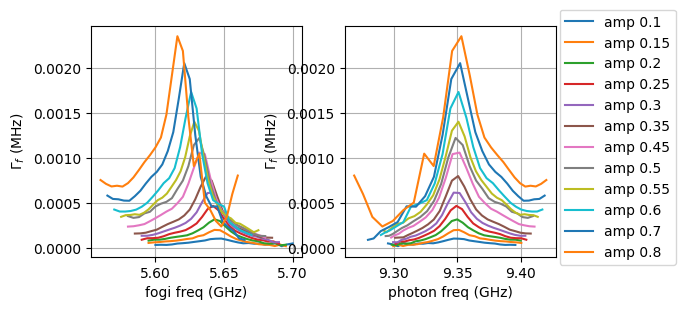

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}


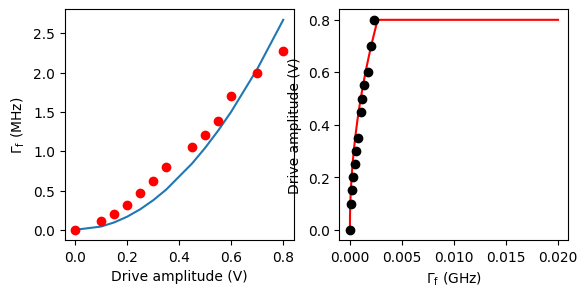

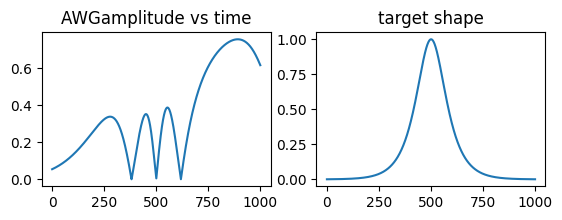

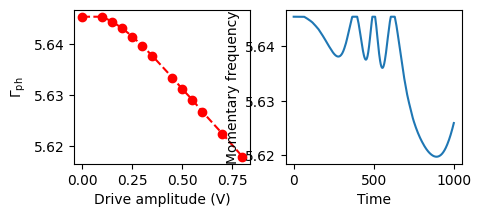

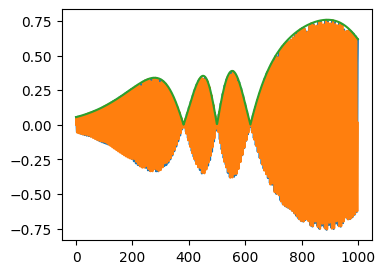

In [168]:
form = "sech_3"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [56]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.33, 9.35, 9.37]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape_othogonal.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.001648235046157298, 'a4': 8.975487020279616e-12, 'a6': 1.8698376180736886e-12, 'a8': 2.2213342276700132e-12, 'a10': 2.220446049250313e-16}
{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
{'a0': 0, 'a2': 0.002245387841872004, 'a4': 3.780087354243733e-12, 'a6': 1.894262524615442e-12, 'a8': 4.0478731477833207e-13, 'a10': 3.228528555609955e-13}


In [57]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[277 380 449 498 552 617 890]


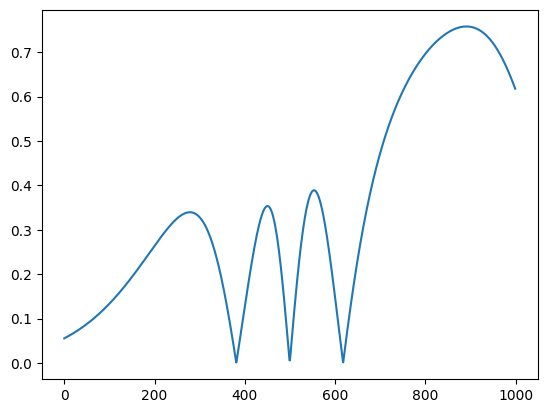

In [58]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

In [169]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="192523"),
    data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="193212"),
    data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="193901"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

overlap 0.9666289498179792
overlap 0.9390596942265994
overlap 0.9861189845298893


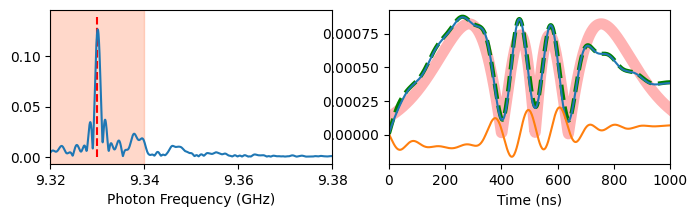

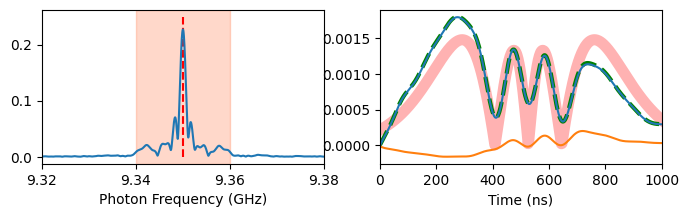

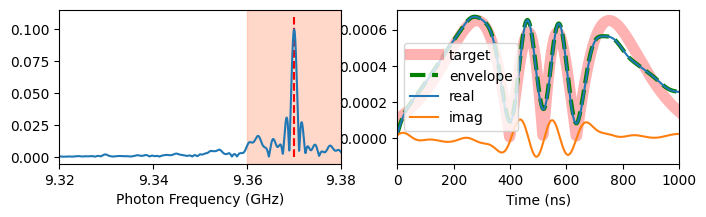

In [170]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_3')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
plt.legend()

1000
1000
1000


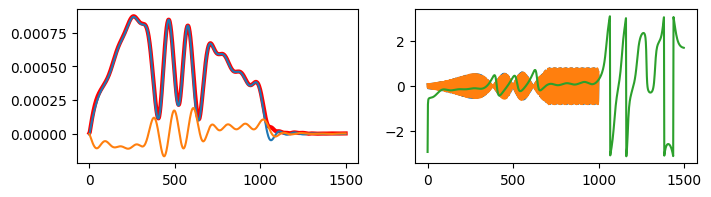

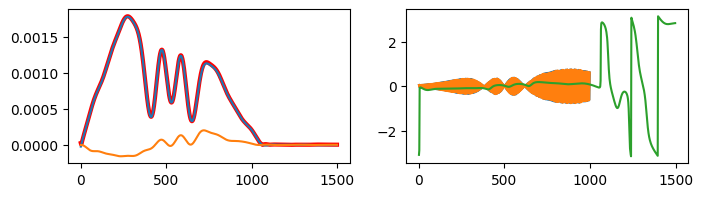

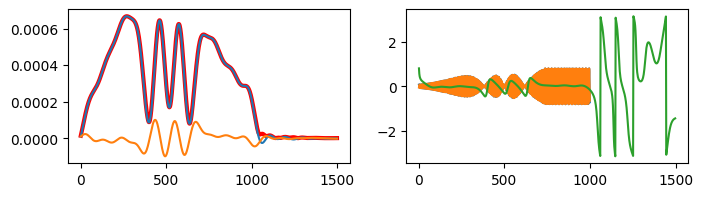

In [83]:
import itertools

# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    print(len(new_ctrl_pulse))
    for i in itertools.chain(range(0, 380), range(498, 617)):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse_othogonal") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape_othogonal.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [171]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="203935"),
    data1 = dict(target_freq=9.35, date="2024-09-22", acquire_time="204625"),
    data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="205314"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

 overlap 0.9600823553173838
 overlap 0.9476589744333279
 overlap 0.9754849001771907


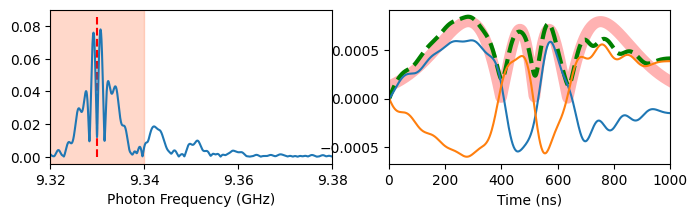

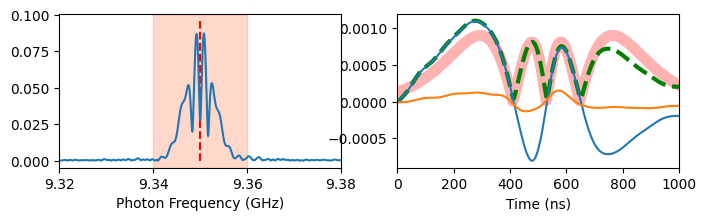

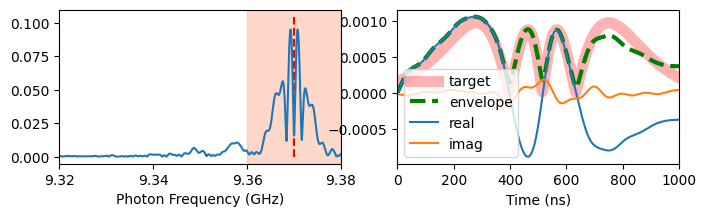

In [172]:
passing_band = 0.01
duration=1000
cd = "CDY166"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f" overlap {target_overlap(signal, time, curve='sech_3')}")
plt.legend()

receive

In [ ]:
result_dict = dict(
    data1 = dict(target_freq=10.3875, date="2024-07-26", acquire_time="161818"),
)

In [ ]:
date = "2024-07-29"
acquire_time="052057"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse_othogonal") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape_othogonal.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )